---
tags: [integration, optimization, variational]
---

# QURI Partsサポート

このページでは、具体的な最適化問題を題材に、Qamomileの[QURI Parts](https://quri-parts.qunasys.com/)バックエンドを紹介します。小さなMaxCutインスタンスを `BinaryModel.from_ising` でIsing問題としてモデル化し、QAOAアンザッツを `@qkernel` として直接記述したうえで、 `QuriPartsTranspiler` / `QuriPartsExecutor` を介して実行します。 `QuriPartsExecutor` は、既定で高速なC++製状態ベクトルシミュレータである[Qulacs](https://docs.qulacs.org/)を使用するため、追加の設定なしにローカルCPU上で以下の例を実行できます。

In [1]:
# 最新のQamomileをQURI Partsオプション付きでpipからインストールします。
# !pip install "qamomile[quri_parts]"

## MaxCut問題

QURI Parts連携の説明に集中するため、[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じ5ノードの小さなグラフを再利用します。 $\sum_{(i,j) \in E}(1 - s_i s_j)/2$ を最大化することは、定数項を除いて、反強磁性Isingハミルトニアン $H_C = \sum_{(i,j) \in E} s_i s_j$ を*最小化*することと等価です。重みなしMaxCutではすべての $J_{ij} = 1$ 、 $h_i = 0$ なので、これらの係数をそのまま `BinaryModel.from_ising` に渡します。モデルオブジェクトは純粋な問題コンテナとして使い、 `quad` / `linear` の辞書を後述のQAOAカーネルに渡すこと、そして測定カウントをspin(+1 / -1)サンプルへ変換するための `decode_from_sampleresult` ヘルパーを提供する役目だけを担います。

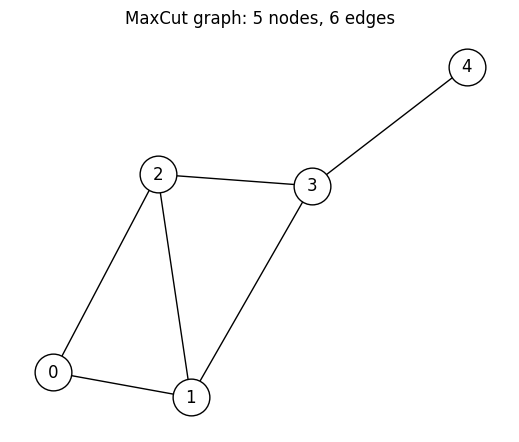

In [2]:
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qamomile.optimization.binary_model import BinaryModel

G = nx.Graph()
G.add_edges_from([(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (3, 4)])
num_nodes = G.number_of_nodes()

ising_quad: dict[tuple[int, int], float] = {
    tuple(sorted((i, j))): 1.0 for i, j in G.edges()
}
ising_linear: dict[int, float] = {}
spin_model = BinaryModel.from_ising(linear=ising_linear, quad=ising_quad)

pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(5, 4))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"MaxCut graph: {num_nodes} nodes, {G.number_of_edges()} edges")
plt.show()

## `@qkernel` によるQAOAアンザッツの構築

`QAOAConverter` を経由する代わりに(内部でトランスパイルしてしまい、カーネルが隠れてしまうため)、QAOAアンザッツを小さな `@qkernel` として直接書きます。こうすることで、QURI Partsへ渡す前に `kernel.draw()` でQamomile側のIRを確認できます。

レシピは[MaxCutに対するQAOAチュートリアル](../algorithm/qaoa_maxcut.ipynb)と同じです。一様重ね合わせから始め、 $p$ 回ぶんのコスト層+ミキサー層を適用し、最後に測定を行います。Qamomileの回転ゲートに含まれる $1/2$ 係数は変分角度に吸収させ、 `rzz` には $J_{ij} \cdot \gamma$ を、 `rx` には $2\beta$ を渡します。

In [3]:
import qamomile.circuit as qmc


@qmc.qkernel
def superposition(n: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
    q = qmc.qubit_array(n, name="q")
    for i in qmc.range(n):
        q[i] = qmc.h(q[i])
    return q


@qmc.qkernel
def cost_layer(
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    q: qmc.Vector[qmc.Qubit],
    gamma: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    for (i, j), Jij in quad.items():
        q[i], q[j] = qmc.rzz(q[i], q[j], angle=Jij * gamma)
    for i, hi in linear.items():
        q[i] = qmc.rz(q[i], angle=hi * gamma)
    return q


@qmc.qkernel
def mixer_layer(
    q: qmc.Vector[qmc.Qubit],
    beta: qmc.Float,
) -> qmc.Vector[qmc.Qubit]:
    n = q.shape[0]
    for i in qmc.range(n):
        q[i] = qmc.rx(q[i], angle=2.0 * beta)
    return q


@qmc.qkernel
def qaoa_ansatz(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = superposition(n)
    for layer in qmc.range(p):
        q = cost_layer(quad, linear, q, gammas[layer])
        q = mixer_layer(q, betas[layer])
    return qmc.measure(q)

`qaoa_ansatz.draw(...)` でQamomileレベルのIRを描画できます。問題構造側の引数( `p` 、 `quad` 、 `linear` 、 `n` )には具体値を渡して層の構造が見えるようにし、 `gammas` / `betas` はシンボリックなまま残します。

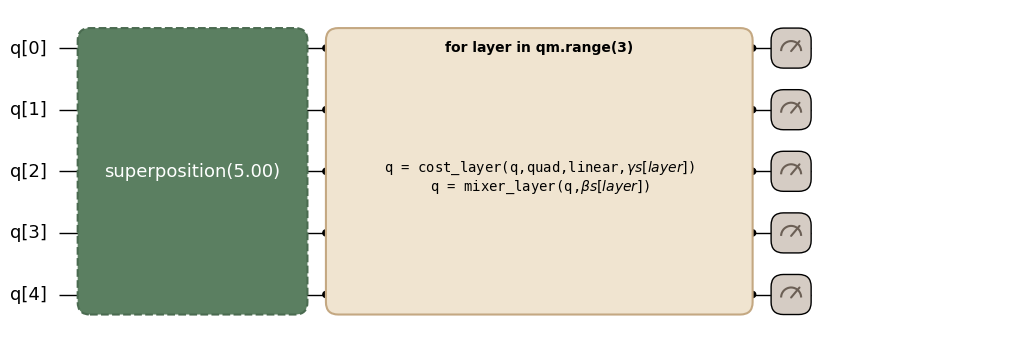

In [4]:
p = 3  # QAOA層数
qaoa_ansatz.draw(
    p=p,
    quad=spin_model.quad,
    linear=spin_model.linear,
    n=num_nodes,
)

## QURI Partsへのトランスパイル

`QuriPartsTranspiler` は他のバックエンドと同じやり方で `transpile()` に渡せます。問題構造側の引数をbindingsで固定し、 `gammas` / `betas` はランタイムパラメータとして残します。

In [5]:
from qamomile.quri_parts import QuriPartsExecutor, QuriPartsTranspiler

transpiler = QuriPartsTranspiler()
executor = QuriPartsExecutor()

executable = transpiler.transpile(
    qaoa_ansatz,
    bindings={
        "p": p,
        "quad": spin_model.quad,
        "linear": spin_model.linear,
        "n": num_nodes,
    },
    parameters=["gammas", "betas"],
)

`executable.get_first_circuit()` で内部のQURI Parts回路が取り出せます。これは確かにQURI Partsの `LinearMappedParametricQuantumCircuit` (公開APIでは `LinearMappedUnboundParametricQuantumCircuit` という別名)であり、 $2p$ 個のQAOA角度( `gammas[0..p-1]` 、 `betas[0..p-1]` )が名前付きランタイムパラメータとして残っています。 `type(...)` とパラメータ数からこれを確認し、さらにQURI Parts組み込みの `draw_circuit` で回路そのものを描画してみましょう。

In [6]:
from quri_parts.circuit.utils.circuit_drawer import draw_circuit

quri_circuit = executable.get_first_circuit()
assert quri_circuit is not None  # transpile()はここで必ず1つの量子セグメントを生成する
print(type(quri_circuit).__name__)
print("qubit_count    :", quri_circuit.qubit_count)
print("parameter_count:", quri_circuit.parameter_count)

draw_circuit(quri_circuit, line_length=200)

LinearMappedParametricQuantumCircuit
qubit_count    : 5
parameter_count: 6
   ___     ___     ___     ___                     ___     ___     ___                     ___     ___     ___                                  
  | H |   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                   |PPR|   |PPR|   |PRX|                                 
--|0  |---|5  |---|6  |---|11 |-------------------|16 |---|17 |---|22 |-------------------|27 |---|28 |---|33 |---------------------------------
  |___|   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                   |   |   |_ _|   |___|                                 
   ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___    |   |    | |     ___     ___     ___                  
  | H |   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|   |   |    | |    |PPR|   |PPR|   |PRX|                 
--|1  |---|   |----| |----|7  |---|8  |---|12 |---|   |

各ランタイムパラメータのスロットは実行時までunboundのままなので、 `gammas` / `betas` のバインドはQURI Parts側での回路の作り直しではなく、安価な数値更新になります。問題の構造(Ising係数、量子ビット数、層数)はコンパイル時に固定され、ランタイム入力として残るのは変分角度だけです。

## `QuriPartsExecutor` によるQAOAサンプリング

`executable.sample(executor, bindings=..., shots=...)` は `SampleJob` を返します。 `.result()` で得られる `SampleResult` は、 `BinaryModel.decode_from_sampleresult` でspinドメイン(+1 / -1)の `BinarySampleSet` へデコードできます。そのため、追加の変換なしにそのままcut辺を数えられます。 `QuriPartsExecutor()` はデフォルトでQulacs状態ベクトルシミュレータ上で動作します。

In [7]:
rng = np.random.default_rng(42)
init_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
init_gammas = list(init_params[:p])
init_betas = list(init_params[p:])
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2000
maxiter = 20 if docs_test_mode else 100

sample_result = executable.sample(
    executor,
    bindings={"gammas": init_gammas, "betas": init_betas},
    shots=sample_shots,
).result()

decoded = spin_model.decode_from_sampleresult(sample_result)
print(f"Mean energy at random init: {decoded.energy_mean():+.4f}")

Mean energy at random init: -0.7170


## QAOAパラメータの最適化

同じ `executable` を異なる `(gammas, betas)` で繰り返し呼び出すのが、QAOA最適化ループの基本的な使い方です。 `transpiler.transpile()` を1回呼び、その後は `executable.sample()` を何度も呼び出します。以下では、sampleとdecodeの処理をSciPyの `minimize` で包みます。古典オプティマイザが `(gammas, betas)` を更新してサンプリングしたIsingエネルギーの平均を最小化する一方、各反復では同じ `executable` と `QuriPartsExecutor` を再利用します。

In [8]:
from scipy.optimize import minimize

cost_history: list[float] = []


def cost_fn(params: np.ndarray) -> float:
    result = executable.sample(
        executor,
        bindings={"gammas": list(params[:p]), "betas": list(params[p:])},
        shots=sample_shots,
    ).result()
    energy = spin_model.decode_from_sampleresult(result).energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(cost_fn, init_params, method="COBYLA", options={"maxiter": maxiter})

opt_gammas = list(res.x[:p])
opt_betas = list(res.x[p:])
print(f"Optimized mean energy: {res.fun:+.4f}")
print(f"Optimal gammas       : {[round(float(v), 4) for v in opt_gammas]}")
print(f"Optimal betas        : {[round(float(v), 4) for v in opt_betas]}")

Optimized mean energy: -2.8210
Optimal gammas       : [0.8935, -0.3261, 1.5125]
Optimal betas        : [0.4784, -0.7959, 2.9381]


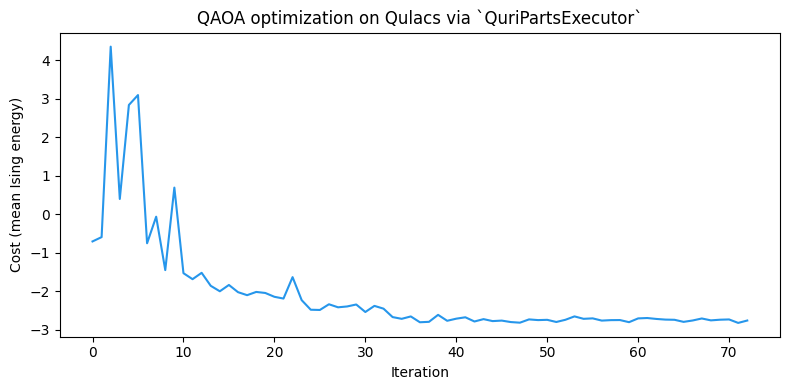

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean Ising energy)")
plt.title("QAOA optimization on Qulacs via `QuriPartsExecutor`")
plt.tight_layout()
plt.show()

`QuriPartsExecutor` が使うQulacs samplerはショットごとのRNGにseedを設定しないため、最適化軌跡や最終エネルギーは実行ごとに多少変動します。それでも、この5ノードグラフ上の $H_C$ の基底状態エネルギー付近までは収束するはずです。上で得た最適パラメータ( `opt_gammas` 、 `opt_betas` )を、以降の例でも使います。

## 期待値: unbound parametric回路とbound回路のdispatch

`QuriPartsExecutor.estimate_expectation(circuit, hamiltonian, param_values)` は、QURI Partsネイティブな期待値評価のエントリポイントです。受け取った**回路の状態**に応じて、内部で2つの異なるQURI Parts estimatorを自動的に切り替えます。

- **Unbound parametricな回路**: `transpile()` が生成したlinear-mapped回路はまだフリーパラメータを持っています。QURI Partsの `apply_circuit` がこれを `ParametricCircuitQuantumState` としてラップし、executorはQURI Partsの**parametric estimator**に処理を回します。この経路では、評価時に `param_values` を使ってパラメータをバインドします。
- **Boundまたは非parametricな回路**: 一度パラメータがバインドされると(例えば `circuit.bind_parameters([...])` を呼ぶと)、同じ `apply_circuit` は `GeneralCircuitQuantumState` を生成します。executorはQURI Partsの**non-parametric estimator**にフォールバックし、 `param_values` は無視されます。

どちらの経路が選ばれるかを知っておく意味は、2つのestimatorのコスト特性が異なることにあります。タイトな最適化ループの中では、反復ごとに回路をコピーしなくてよいparametric estimatorが適しています。一方、パラメータがすでに具体化されているなら、non-parametric estimatorのほうがparametric固有のオーバーヘッドを避けられます。

QURI Partsは回路レベルでは `measure` をno-opとして扱うため、 `transpiler.transpile(qaoa_ansatz, ...)` が出すparametric回路はそのままQAOA状態 $|\boldsymbol{\gamma}, \boldsymbol{\beta}\rangle$ の準備を表します。これをコストハミルトニアンと一緒に `estimate_expectation` へ渡せば、 $\langle H_C \rangle$ をサンプリングノイズなしで解析的に計算できます。したがってQAOAオプティマイザの中では、同じ回路のまま `executable.sample()` +decodeを `executor.estimate(circuit, hamiltonian, params=...)` に置き換えられます。

両方のestimator経路を直接試したいときは、Qamomileの `Hamiltonian` として $H_C = \sum_{(i,j) \in E} Z_i Z_j$ (および線形項 $h_i$ 。重みなしMaxCutでは空)を組み立て、それをQURI PartsのOperatorに変換してから、それぞれの回路に対して `estimate_expectation` を呼びます。

In [10]:
import qamomile.observable as qm_o
from qamomile.quri_parts.observable import hamiltonian_to_quri_operator

cost_hamiltonian = qm_o.Hamiltonian()
for (i, j), Jij in spin_model.quad.items():
    cost_hamiltonian.add_term(
        (qm_o.PauliOperator(qm_o.Pauli.Z, i), qm_o.PauliOperator(qm_o.Pauli.Z, j)),
        Jij,
    )
for i, hi in spin_model.linear.items():
    cost_hamiltonian.add_term((qm_o.PauliOperator(qm_o.Pauli.Z, i),), hi)

quri_H = hamiltonian_to_quri_operator(cost_hamiltonian)

# transpiler.transpile()直後のunbound parametric回路
unbound_circuit = executable.get_first_circuit()
assert unbound_circuit is not None
print(f"unbound type           : {type(unbound_circuit).__name__}")
print(f"unbound parameter_count: {unbound_circuit.parameter_count}")

# QURI Partsはランタイムパラメータを「回路に登録された順序のフラットなリスト」
# として要求します。登録順は回路emit時のfirst-use順なので、QAOAでは
# gammas[0], betas[0], gammas[1], betas[1], ... と層ごとに交互の順になります。
# 「全gammasに続いて全betas」ではない点に注意してください。
# 規約を推測しなくて済むよう、executableから順序を読み、lookupでフラット化します。
named_values = {f"gammas[{i}]": opt_gammas[i] for i in range(p)}
named_values.update({f"betas[{i}]": opt_betas[i] for i in range(p)})
flat_params = [named_values[name] for name in executable.parameter_names]
print(f"circuit parameter order: {executable.parameter_names}")

# QURI Partsのネイティブbinderで同じ数値を手動でバインド
bound_circuit = unbound_circuit.bind_parameters(flat_params)
print(f"bound   type           : {type(bound_circuit).__name__}")

# 経路1: unbound -> parametric estimator。param_valuesが消費されます
energy_unbound = executor.estimate_expectation(
    unbound_circuit, quri_H, flat_params
)

# 経路2: bound -> non-parametric estimator。param_valuesは無視されます
energy_bound = executor.estimate_expectation(bound_circuit, quri_H, [])

print(f"parametric  estimator: {energy_unbound:+.10f}")
print(f"non-param.  estimator: {energy_bound:+.10f}")
assert np.isclose(energy_unbound, energy_bound, atol=1e-10)

unbound type           : LinearMappedParametricQuantumCircuit
unbound parameter_count: 6
circuit parameter order: ['gammas[0]', 'betas[0]', 'gammas[1]', 'betas[1]', 'gammas[2]', 'betas[2]']
bound   type           : ImmutableBoundParametricQuantumCircuit
parametric  estimator: -2.7452592307
non-param.  estimator: -2.7452592307


両経路は数値精度の範囲で一致します。同じQAOA状態を同じIsingコストハミルトニアンに対して評価しているからです。さらに、最適化後のパラメータにおけるこのノイズなしの期待値は、先ほど出力した最適化済みの標本平均エネルギーともショットノイズの範囲で一致するはずです。このdispatchはQamomileの `executor.estimate()` インターフェースの中に隠れているので、利用者は通常意識せずに済みます。自分でQURI Parts回路を直接扱う事情があるときだけ、 `estimate_expectation` を直接呼べば十分です。

`executor.estimate(circuit, hamiltonian, params=...)` は1段上のバリアントです。 `qamomile.observable.Hamiltonian` を直接受け取り、内部で自動変換してから `estimate_expectation` に委譲します。

In [11]:
energy_via_estimate = executor.estimate(
    unbound_circuit, cost_hamiltonian, params=flat_params
)
print(f"executor.estimate     : {energy_via_estimate:+.10f}")
assert np.isclose(energy_via_estimate, energy_unbound, atol=1e-10)

executor.estimate     : -2.7452592307


## samplerとestimatorのカスタマイズ

`QuriPartsExecutor()` は、初回利用時にデフォルトのQulacs vector samplerとparametric estimatorを遅延生成します。別のQURI Partsバックエンドを差し込むには、 `QuriPartsTranspiler.executor(sampler=..., estimator=...)` 経由でsampler(あるいはestimator)を渡すか、 `QuriPartsExecutor(sampler=..., estimator=...)` を直接インスタンス化します。カスタムexecutorは、上で使った `executor` をそのまま差し替えるだけで動きます。samplerを変えてもkernelをトランスパイルし直す必要はありません。executableが回路を持ち、executorがシミュレーションバックエンドを持つためです。

具体例として、QURI PartsのQulacs `NoiseSimulator` を使ったノイズあり samplerを構築し、**同じ**最適化済みパラメータに対するノイズなし/ノイズありの標本平均エネルギーを並べて比較してみます。すべてのゲートに対して非自明なdepolarizingチャネルが掛かれば、ノイズあり側の平均エネルギーはノイズなしの値からずれるはずです。これにより、カスタムsamplerがちゃんとループに組み込まれていることが確認できます。

In [12]:
from quri_parts.circuit.noise import DepolarizingNoise, NoiseModel
from quri_parts.qulacs.sampler import create_qulacs_noisesimulator_sampler

noise_model = NoiseModel([DepolarizingNoise(error_prob=0.02)])
noisy_sampler = create_qulacs_noisesimulator_sampler(noise_model)
noisy_executor = transpiler.executor(sampler=noisy_sampler)

clean_result = executable.sample(
    executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()
noisy_result = executable.sample(
    noisy_executor,
    bindings={"gammas": opt_gammas, "betas": opt_betas},
    shots=sample_shots,
).result()

clean_energy = spin_model.decode_from_sampleresult(clean_result).energy_mean()
noisy_energy = spin_model.decode_from_sampleresult(noisy_result).energy_mean()
print(f"noiseless sampler mean energy: {clean_energy:+.4f}")
print(f"noisy     sampler mean energy: {noisy_energy:+.4f}")

noiseless sampler mean energy: -2.7570
noisy     sampler mean energy: -1.4970


depolarizingチャネルはQAOA状態を最大混合状態に向けて混ぜていくので、その極限ではすべてのspin配置が等確率になり $H_C$ の平均は $0$ に収束します。したがってノイズあり側の平均エネルギーは、ノイズなしよりも0に近い(より高い)値になります。 `error_prob` を上げたり、追加のノイズチャネルを重ねたりすれば、ノイズあり側のエネルギーはさらに $0$ に押し寄せられます。逆に `error_prob=0.0` にすればショットノイズの範囲でノイズなしの値に戻ります。リモートデバイス、density-matrixシミュレータ、stochastic state-vector samplerなど他のQURI Parts samplerに差し替える場合も同じパターンで動き、いずれもkernelの再トランスパイルは不要です。

## まとめ

- QAOAアンザッツを `@qkernel` として直接記述すれば、 `kernel.draw()` でIRをそのまま確認できます。 `BinaryModel.from_ising` は純粋な問題コンテナとして利用し、 `quad` / `linear` をカーネルに渡したり、サンプリング結果をspinドメインへデコードする役割だけを担います。
- `QuriPartsTranspiler().transpile(kernel, bindings=..., parameters=[...])` はカーネルをQURI Partsの `LinearMappedParametricQuantumCircuit` まで降下させ、QURI Partsネイティブの `draw_circuit` でそのまま確認できます。
- `QuriPartsExecutor` は、デフォルトのQulacs状態ベクトルシミュレータに対して、QAOA風サンプリングのための `executable.sample()` と、ノイズなしの期待値評価のための `executor.estimate(...)` の両方をサポートします。
- `estimate_expectation` は、入力回路にフリーパラメータが残っているかどうかに応じて、QURI Partsのparametric estimatorとnon-parametric estimatorを切り替えます。通常は `executor.estimate()` がdispatchを隠しますが、Qamomileの高水準インターフェースの外で連携するときには直接呼び出すこともできます。
- QURI Partsの `NoiseSimulator` ベースのsamplerを含むカスタムのsampler/estimatorは `transpiler.executor(...)` 経由で差し替えられ、kernelをトランスパイルし直す必要はありません。上の例で示したとおり、実際にサンプリング分布が変わることが確認できます。